# Sky Subtraction Accelerated by CUDA

This notebook demonstrates how to use CUDA to perform sky subtraction on astronomical images.

In [2]:
from astropy.io import fits
import cupy as cp

import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval
interval = ZScaleInterval()

def load_image(image_path, hdu_id=0):
    with fits.open(image_path) as hdul:
        data = hdul[hdu_id].data
        
    return data

## The sky subtraction algorithm used by Source Extractor [(link)](https://sextractor.readthedocs.io/en/latest/Background.html)

- Divide an image into meshgrids with a size of 64 * 64 pixels.
- Apply 3-sigma-clip in each meshgrid for 5 iterations.  Estimate the sky and get a map of the background.
- Smooth the background map using a 3*3 median filter. (This step is crucial.)
- Interpolate the map to the image size.

The Source Extractor software also considers edge cases. For simplicity, we ignore those cases.

Some functions in this demo could be improved:

- The time complexity of the sorting algorithm in the `compute_median` is O(n^2), which could be better.
- `interpolate_background` needs more tests for using the `ceil` function in edge cases. The interpolation formula also needs to be verified.
- `expand_mesh_map` is not parallelized.
- The rightmost and bottommost blocks may have smaller sizes, which are not explicitly handled in `expand_mesh_map`. This problem is inevitable since the image size is not always a multiple of the mesh size.

In [4]:
INPUT_IMAGE_PATTERN = ("/global/cfs/cdirs/lsst/shared/external/roman-desc-sims/Roman_data"
                          "/RomanTDS/images/simple_model/{band}/{pointing}/Roman_TDS_simple_model_{band}_{pointing}_{sca}.fits.gz")

image_id = {'band': 'R062', 'pointing': 26565, 'sca': 18}
image_path = INPUT_IMAGE_PATTERN.format(**image_id)
image = load_image(image_path, hdu_id=1)

image_skysub = load_image("./temp/skysub_Roman_TDS_simple_model_{band}_{pointing}_{sca}.fits.gz".format(**image_id))

In [5]:
print(image.dtype)

>f8


In [10]:
import warnings
import cupy as cp
from cupyx.scipy import ndimage

compute_background_map_raw = r'''
extern "C"{

__device__ void get_local_xy_from_mesh(int mesh_idx, int mesh_size, int* local_x, int* local_y) {
    *local_x = mesh_idx % mesh_size;
    *local_y = mesh_idx / mesh_size;
}

__device__ void get_global_xy_from_local(int local_x, int local_y, int start_x, int start_y, int* global_x, int* global_y){
    *global_x = start_x + local_x;
    *global_y = start_y + local_y;
}

__device__ void initialize_tile(float* image, int* image_mask,
                                float* tile, int* tile_mask, int tid,
                                int start_x, int start_y,
                                int width, int height,
                                int mesh_size, int num_threads){
     // load pixels to array
     for (int i = tid; i < mesh_size * mesh_size; i += num_threads) {
         int local_x, local_y, global_x, global_y;
         
         get_local_xy_from_mesh(i, mesh_size, &local_x, &local_y);
         get_global_xy_from_local(local_x, local_y, start_x, start_y, &global_x, &global_y);
         
         int global_idx = global_y * width + global_x;

         if (0 <= global_x && global_x < width && 0 <= global_y && global_y < height){
             tile[i] = image[global_idx];
             tile_mask[i] = image_mask[global_idx];
         }
         else {
             tile[i] = 0.0f;
             tile_mask[i] = 1; // 1 = unusable
         }
     }

     __syncthreads();
     
}

__device__ void compute_local_stats(float* tile, int* tile_mask, int tid, int tile_size, int num_threads,
                                    float* local_sum, float* local_sum_sq, int* local_count){
    for (int i=tid; i < tile_size; i += num_threads){
        if (tile_mask[i] == 0){
            *local_sum += tile[i];
            *local_sum_sq += tile[i] * tile[i];
            *local_count += 1;       
        }
    }
}

__device__ void compute_sigmaclip_bound(float block_sum, float block_sum_sq,
                                        int block_count, int n_sigma,
                                        float* lower, float* upper){
    float mean = block_sum / block_count;
    float std = sqrt(fmaxf(block_sum_sq / block_count - mean * mean, 0.0f));
    *lower = mean - std * n_sigma;
    *upper = mean + std * n_sigma;
}

__device__ void update_tile_mask(float* tile, int* tile_mask, 
                            int tid, int tile_size, int num_threads,
                            float lower, float upper){          
    for (int i = tid; i < tile_size; i += num_threads){
        if (tile_mask[i] == 0) tile_mask[i] |= (tile[i] < lower || tile[i] > upper);
    }
}

__device__ void perform_sigmaclip(float* tile, int* tile_mask,
                                  float* block_sum, float* block_sum_sq, int* block_count,
                                  float n_sigma, float* background_map, int background_idx,
                                  int tid, int tile_size, int num_threads, int max_iter){
    for (int iter = 0; iter < max_iter; ++iter){
        
        if (tid == 0){
            *block_sum = 0.0f;
            *block_sum_sq = 0.0f;
            *block_count = 0; // block_count keeps track of pixels used
            } 
            
        __syncthreads(); // ensure initialization is done

        float local_sum = 0.0f, local_sum_sq = 0.0f;
        int local_count = 0;
        
        compute_local_stats(tile, tile_mask, tid, tile_size, num_threads,
                            &local_sum, &local_sum_sq, &local_count);
        
        atomicAdd(block_sum, local_sum);
        atomicAdd(block_sum_sq, local_sum_sq);
        atomicAdd(block_count, local_count);
        __syncthreads();

        float lower = 0.0f, upper = 0.0f;
        
        if (*block_count == 0){
            if (tid == 0) background_map[background_idx] = nanf(""); 
            return;
        }
        else {
            compute_sigmaclip_bound(*block_sum, *block_sum_sq, *block_count, n_sigma, &lower, &upper);
        }
        
        __syncthreads();

        update_tile_mask(tile, tile_mask, tid, tile_size, num_threads, lower, upper);
        __syncthreads();        
     }    
}

__device__ int sort_masked_array(float* arr, int* arr_mask, int arr_length){
    int valid = 0;
    for (int i = 0; i < arr_length; i++){
        if (arr_mask[i] == 0){
            arr[valid] = arr[i];
            valid += 1;
        }
    }
    return valid;
}

__device__ float compute_median(float* array, int length){
    for (int i = 1; i < length; ++i){
        float current = array[i];
        int j = i - 1;
        while(j >= 0 && array[j] > current){
            array[j+1] = array[j];
            j--;
        }
        array[j + 1] = current;
    }

    float median = (length % 2 == 1) ? array[length / 2] : (array[length / 2 - 1] + array[length / 2]) / 2;
    return median;
}

__device__ void compute_output_local_stats(float* tile, int* tile_mask, int tid, int n_clipped, int num_threads,
                                           float* output_local_sum, int* output_local_count){
    for (int i = tid; i < n_clipped; i += num_threads){
        if (tile_mask[i] == 0){
            *output_local_sum += tile[i];
            *output_local_count += 1;
        }    
    }
}

__global__ void compute_background_map(float* image, int* image_mask, float* background_map, float* rms_map,
                                       int mesh_size, int width, int height,
                                       float n_sigma, int max_iter){
     
     const int tx = threadIdx.x, ty = threadIdx.y;
     const int bx = blockIdx.x, by = blockIdx.y;
     
     const int tid = ty * blockDim.x + tx;
     const int num_threads = blockDim.x * blockDim.y;
     

     __shared__ int start_x, start_y;
     
     if (tid == 0){
         // this guarantees blocks at the boundary also have mesh_size * mesh_size pixels
         start_x = (bx * mesh_size > width - mesh_size) ? width - mesh_size : bx * mesh_size;
         start_y = (by * mesh_size > height - mesh_size) ? height - mesh_size: by * mesh_size;
     }

     __syncthreads();

    // The index of the background map
    int background_idx = by * gridDim.x + bx; 

    // Use shared space to load data
    extern __shared__ char shared[];
    float* tile = (float*)shared;
    int tile_size = mesh_size * mesh_size;
    int* tile_mask = (int*)(shared + tile_size * sizeof(float));
     
    initialize_tile(image, image_mask, tile, tile_mask, tid,
                    start_x, start_y, width, height,
                    mesh_size, num_threads);

    __syncthreads();

    __shared__ float block_sum, block_sum_sq;
    __shared__ int block_count;

    perform_sigmaclip(tile, tile_mask, &block_sum, &block_sum_sq, &block_count,
                      n_sigma, background_map, background_idx,
                      tid, tile_size, num_threads, max_iter);
    
    
    // Sigmaclip completed, compute sky background
    __shared__ int n_clipped;
    __shared__ float output_block_sum;
    __shared__ float output_block_sum_sq;
    __shared__ int output_block_count;
    
    if (tid == 0){
        output_block_sum = 0.0f;
        output_block_sum_sq = 0.0f;
        output_block_count = 0;
        
        n_clipped = sort_masked_array(tile, tile_mask, tile_size);
    } 
    __syncthreads();

    float output_local_sum = 0.0f;
    float output_local_sum_sq = 0.0f;
    int output_local_count = 0;
    
    compute_local_stats(tile, tile_mask, tid, n_clipped, num_threads,
                        &output_local_sum, &output_local_sum_sq, &output_local_count); //Use n_clipped as tile size
                                
    atomicAdd(&output_block_sum, output_local_sum);
    atomicAdd(&output_block_sum_sq, output_local_sum_sq);
    atomicAdd(&output_block_count, output_local_count);
    __syncthreads();

    if (tid == 0) {
        if (n_clipped < 0.6f * tile_size){
                background_map[background_idx] = nanf("");
                return;
            }
        else {
            float output_median = compute_median(tile, n_clipped);
            float output_mean =  output_block_sum / output_block_count;
            float output_std = sqrt(
                fmaxf(
                    output_block_sum_sq / output_block_count - output_mean * output_mean, 0.0f
                )
            );
            
            background_map[background_idx] = 2.5 * output_median - 1.5 * output_mean;
            rms_map[background_idx] = output_std;
            }
    }
    __syncthreads();

    
    // End of the function                           
}

}     
'''

def generate_background_map(nx, ny, mesh_size):
    grid_x = (nx + mesh_size - 1) // mesh_size
    grid_y = (ny + mesh_size - 1) // mesh_size
    background_map = cp.zeros((grid_y, grid_x), dtype=cp.float32)
    return background_map

def interpolate_background(background_map, nx, ny, mesh_size):
    """
    The background map is located at the center of the interpolated grid.
    Further tests of this function's use of the ceil function and further inspections of the intepolation formula are needed.
    """
    grid_y, grid_x = background_map.shape
    
    xx, yy = cp.meshgrid(cp.arange(nx), cp.arange(ny), indexing='xy')
    xx, yy = (xx+0.5) / mesh_size - 0.5, (yy+0.5) / mesh_size - 0.5 # Map coordinates into grids
    
    xx0 = cp.floor(xx).astype(cp.int32)
    yy0 = cp.floor(yy).astype(cp.int32)

    xx1 = cp.ceil(xx).astype(cp.int32)
    yy1 = cp.ceil(yy).astype(cp.int32)

    xx0 = cp.clip(xx0, 0, grid_x - 1)
    yy0 = cp.clip(yy0, 0, grid_y - 1)
    xx1 = cp.clip(xx1, 0, grid_x - 1)
    yy1 = cp.clip(yy1, 0, grid_y - 1)

    wx, wy = xx - xx0, yy - yy0

    f00 = background_map[yy0, xx0]
    f01 = background_map[yy1, xx0]
    f10 = background_map[yy0, xx1]
    f11 = background_map[yy1, xx1]

    background = (1 - wy) * ( (1 - wx) * f00 + wx * f10 ) + wy * ( (1 - wx) * f01 + wx * f11 )
    return background

def expand_mesh_map(mesh_map, nx, ny, mesh_size):

    grid_y, grid_x = mesh_map.shape
    expanded = cp.zeros((ny, nx), dtype=mesh_map.dtype)

    for j in range(grid_y):
        for i in range(grid_x):
            start_y = j * mesh_size
            end_y = min((j + 1) * mesh_size, ny)
            start_x = i * mesh_size
            end_x = min((i + 1) * mesh_size, nx)

            expanded[start_y: end_y, start_x: end_x] = mesh_map[j, i]
    
    return expanded

def get_source_mask(arr, arr_rms, detect_thresh=1.5, min_area=5):
    detection_mask = (arr > arr_rms * detect_thresh)
    labeled_arr, num_sources = ndimage.label(detection_mask)
    source_sizes = ndimage.sum_labels(cp.ones_like(arr), labeled_arr, index=cp.arange(1, num_sources + 1))
    valid_sources = cp.where(source_sizes >= min_area)[0] + 1
    source_mask = cp.isin(labeled_arr, valid_sources)
    return source_mask

def fill_nans(background_map):
    filled = background_map.copy()
    nan_mask = cp.isnan(background_map)
    valid = ~nan_mask

    kernel = cp.ones((3, 3), dtype=cp.float32)
    sum_vals = ndimage.convolve(cp.nan_to_num(filled), kernel, mode='constant', cval=0.0)
    count_vals = ndimage.convolve(valid.astype(cp.float32), kernel, mode='constant', cval=0.0)
    
    avg_vals = sum_vals / cp.clip(count_vals, 1, None)
    filled[nan_mask] = avg_vals[nan_mask]
    return filled

def sky_background_cupy(background_map_raw, input_image, input_mask=None, mesh_size=64, threads_per_block=(16, 16), n_sigma=3.0, max_iter=5):
    image = cp.asarray(input_image, dtype=cp.float32)
    ny, nx = image.shape
    if not input_mask:
        image_mask = cp.zeros(image.shape, dtype=cp.int32) # 0 = usable
    background_map = generate_background_map(nx, ny, mesh_size)
    rms_map = cp.zeros(background_map.shape, dtype=cp.float32)
    
    blocks_per_grid = (background_map.shape[1], background_map.shape[0]) # GPU grid dim is set as the same as the number of background meshes

    sigmaclip_kernel = cp.RawKernel(compute_background_map_raw, 'compute_background_map')
    shared_mem = (4 + 4) * mesh_size * mesh_size + 128 # In each block, we need a float for background and an int for mask
    
    sigmaclip_kernel(blocks_per_grid, threads_per_block, (
        image.ravel(), image_mask.ravel(), background_map.ravel(), rms_map, cp.int32(mesh_size), cp.int32(nx), cp.int32(ny),
        cp.float32(n_sigma), cp.int32(max_iter)
        ), shared_mem = shared_mem)

    if cp.isnan(background_map).any():
        warnings.warn('Nan found in background map, all pixels are out of the sigmaclip bound.')
        background_map = fill_nans(background_map)
        
    background_map = ndimage.median_filter(background_map, size=3)

    background = interpolate_background(background_map, nx, ny, mesh_size)
    background_rms = expand_mesh_map(rms_map, image.shape[1], image.shape[0], mesh_size)
    
    background = ndimage.median_filter(background, size=3)
    
    return background, background_rms

In [2]:
""""
def estimate_local_background_in_an_annulus(image, mask, x, y, r_in=15, r_out=25):
    ny, nx = image.shape
    yy, xx = cp.meshgrid(cp.arange(ny), cp.arange(nx), indexing='ij')
    r2 = (xx - x) ** 2 + (yy - y) ** 2
    annulus_mask = (r2 >= r_in**2) & (r2 <= r_out**2)

    if mask is not None:
        annulus_mask &= (mask == 0)

    annulus_pixels = image[annulus_mask]
    if annulus_pixels.size == 0:
        return cp.nan, cp.nan, 0
    return annulus_pixels.mean(), annulus_pixels.std(), annulus_pixels.size
""";

In [13]:
import time

cp.cuda.Device().synchronize()
start = time.time()

image_gpu = cp.asarray(image, dtype=cp.float32)
background, background_rms = sky_background_cupy(compute_background_map_raw, image_gpu, mesh_size=64, threads_per_block=(16, 16), n_sigma=5, max_iter=5)

cp.cuda.Device().synchronize()
end = time.time()

print(f"Elapsed time: {end - start:.4f} seconds")

Elapsed time: 2.3296 seconds


<center><img src="without_median_filter.png" height="1000px" width="1000px"/> </center>

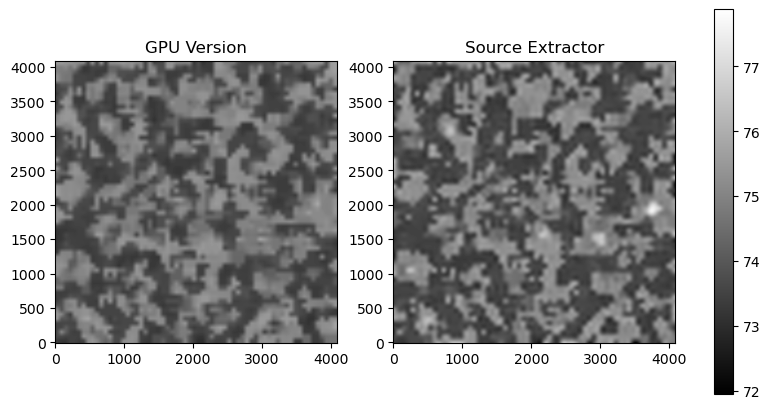

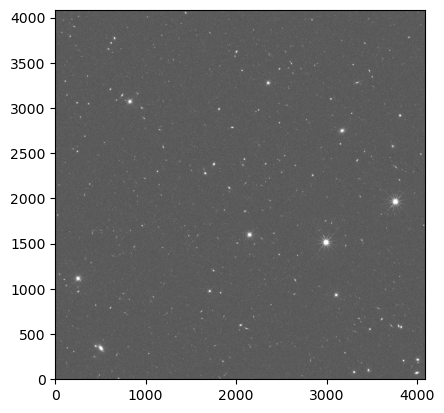

In [17]:
import matplotlib.pyplot as plt

img1 = cp.asnumpy(background)
img2 = image - image_skysub

vmin = min(img1.min(), img2.min())
vmax = max(img1.max(), img2.max())

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
im0 = ax[0].imshow(img1, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
ax[0].set_title('GPU Version')

im1 = ax[1].imshow(img2, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
ax[1].set_title('Source Extractor')

fig.colorbar(im1, ax=ax.ravel().tolist())# , shrink=0.8
plt.show()

plt.figure()
plt.imshow(interval(image), cmap='gray', origin='lower')

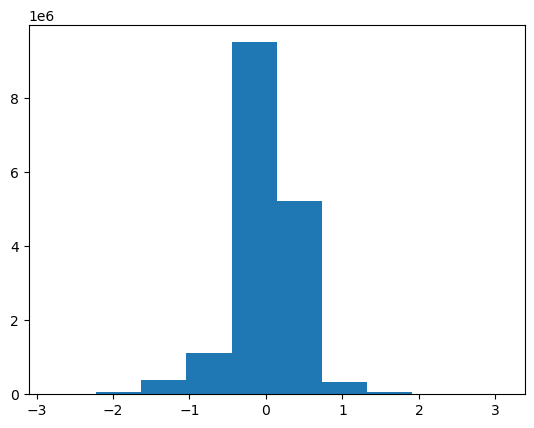

In [12]:
import numpy as np
plt.hist((image - image_skysub - cp.asnumpy(background)).ravel());

# R062

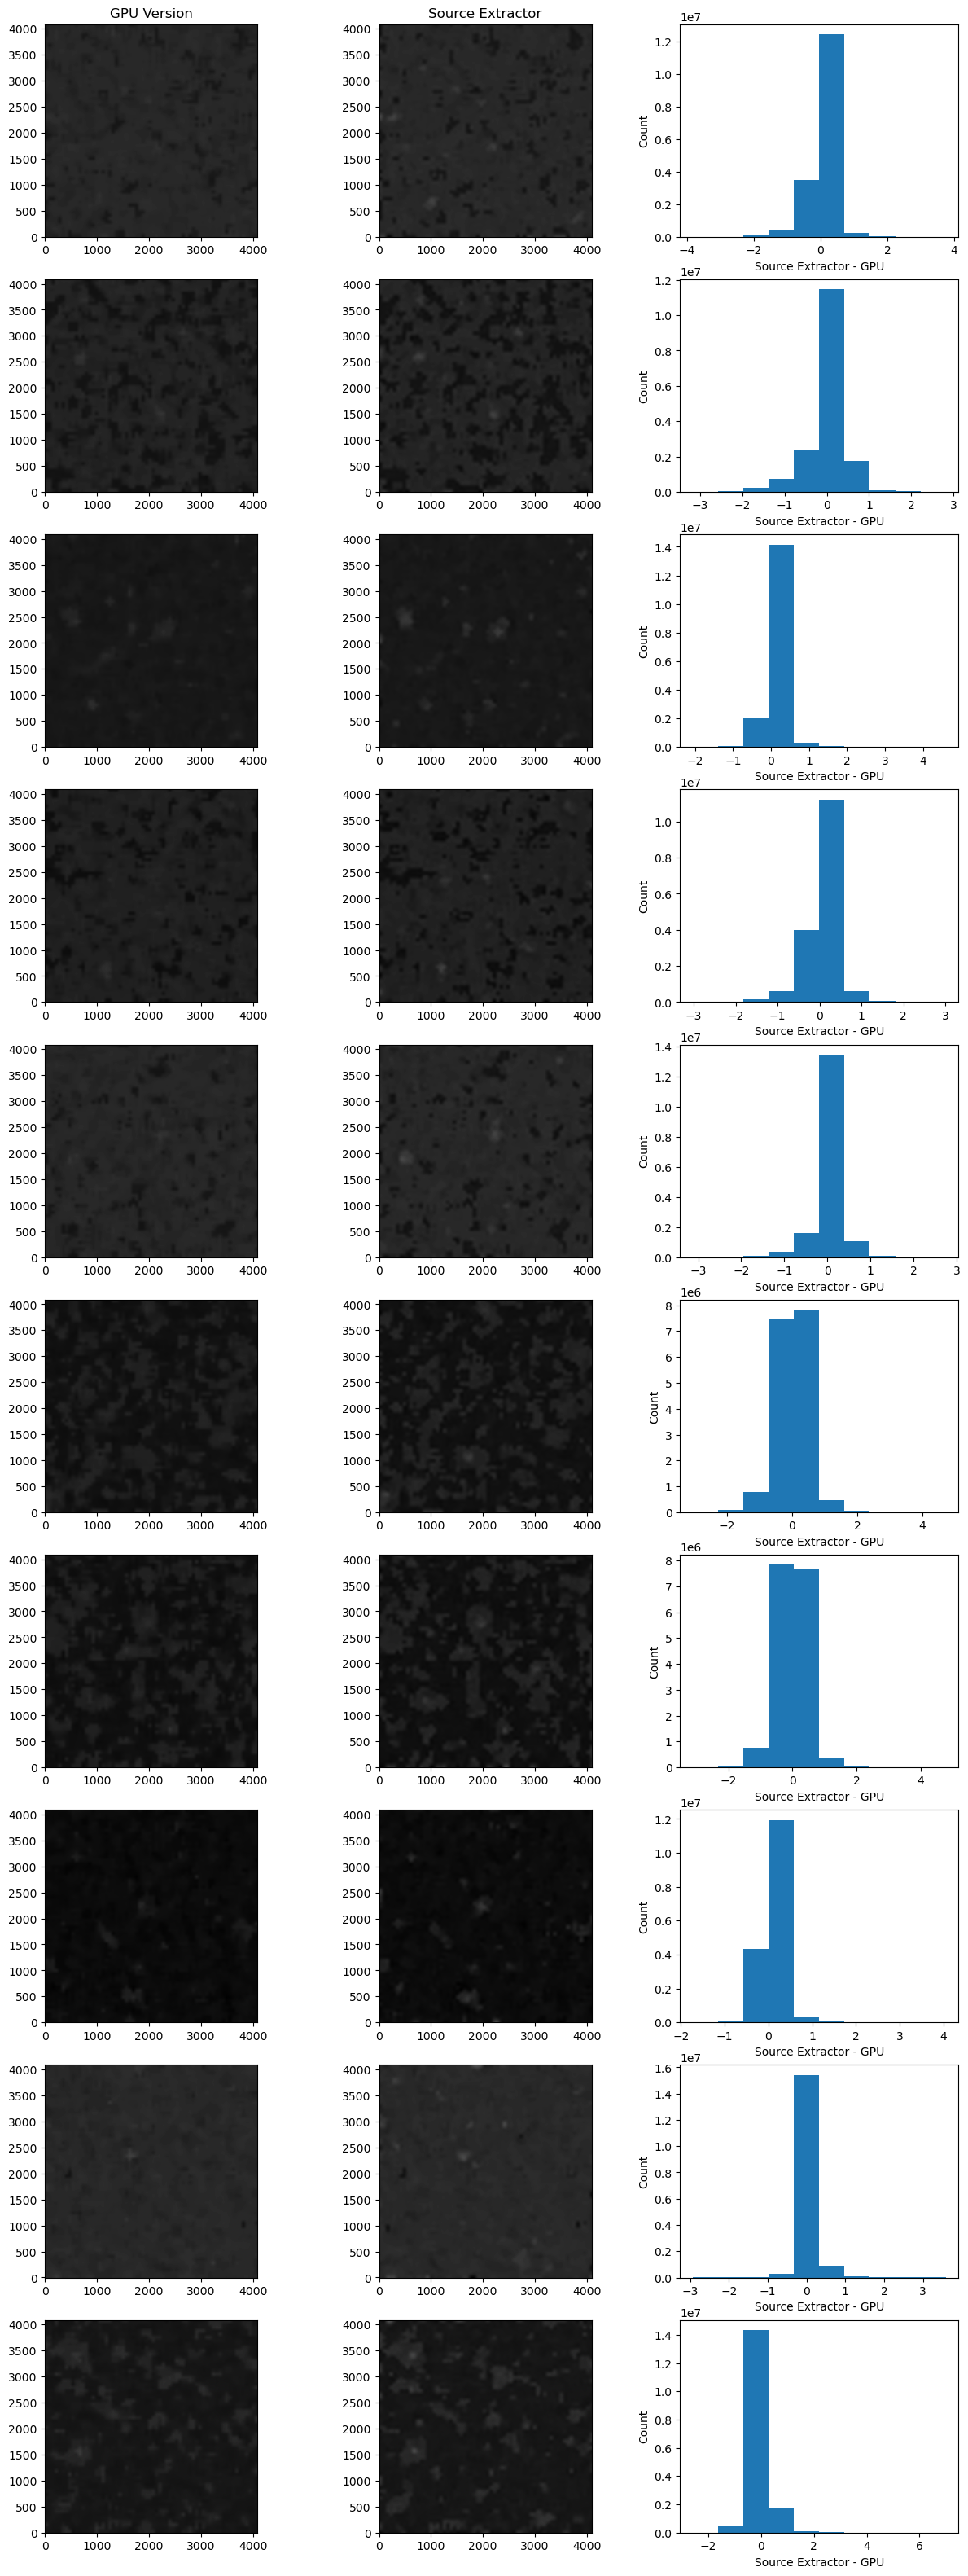

In [18]:
import pandas as pd
sne = pd.read_csv('./detect_supernova/test/test_ten_data_records.csv')

fig, ax = plt.subplots(10, 3, figsize=(15, 40))
for idx, row in sne.iterrows():
    band = str(row['science_band'])
    pointing = int(row['science_pointing'])
    sca = int(row['science_sca'])
    science_id = {'band': band, 'pointing': pointing, 'sca': sca}
    science_path = INPUT_IMAGE_PATTERN.format(**science_id)
    science_image = load_image(science_path, hdu_id=1)
    science_skysub = load_image("./temp/skysub_Roman_TDS_simple_model_{band}_{pointing}_{sca}.fits.gz".format(**science_id))
    background, background_rms = sky_background_cupy(compute_background_map_raw, science_image, mesh_size=64, threads_per_block=(16, 16), n_sigma=5, max_iter=5)

    img1 = cp.asnumpy(background)
    img2 = science_image - science_skysub
    
    vmin = min(img1.min(), img2.min())
    vmax = max(img1.max(), img2.max())
    
    im0 = ax[idx][0].imshow(img1, cmap='gray', origin='lower', vmin=vmin, vmax=vmax*1.2)
    
    
    im1 = ax[idx][1].imshow(img2, cmap='gray', origin='lower', vmin=vmin, vmax=vmax*1.2)

    ax[idx][2].hist((img2 - img1).ravel())
    ax[idx][2].set_xlabel('Source Extractor - GPU')
    ax[idx][2].set_ylabel('Count')

    if idx == 0:
        ax[idx][0].set_title('GPU Version')
        ax[idx][1].set_title('Source Extractor')  

# H158

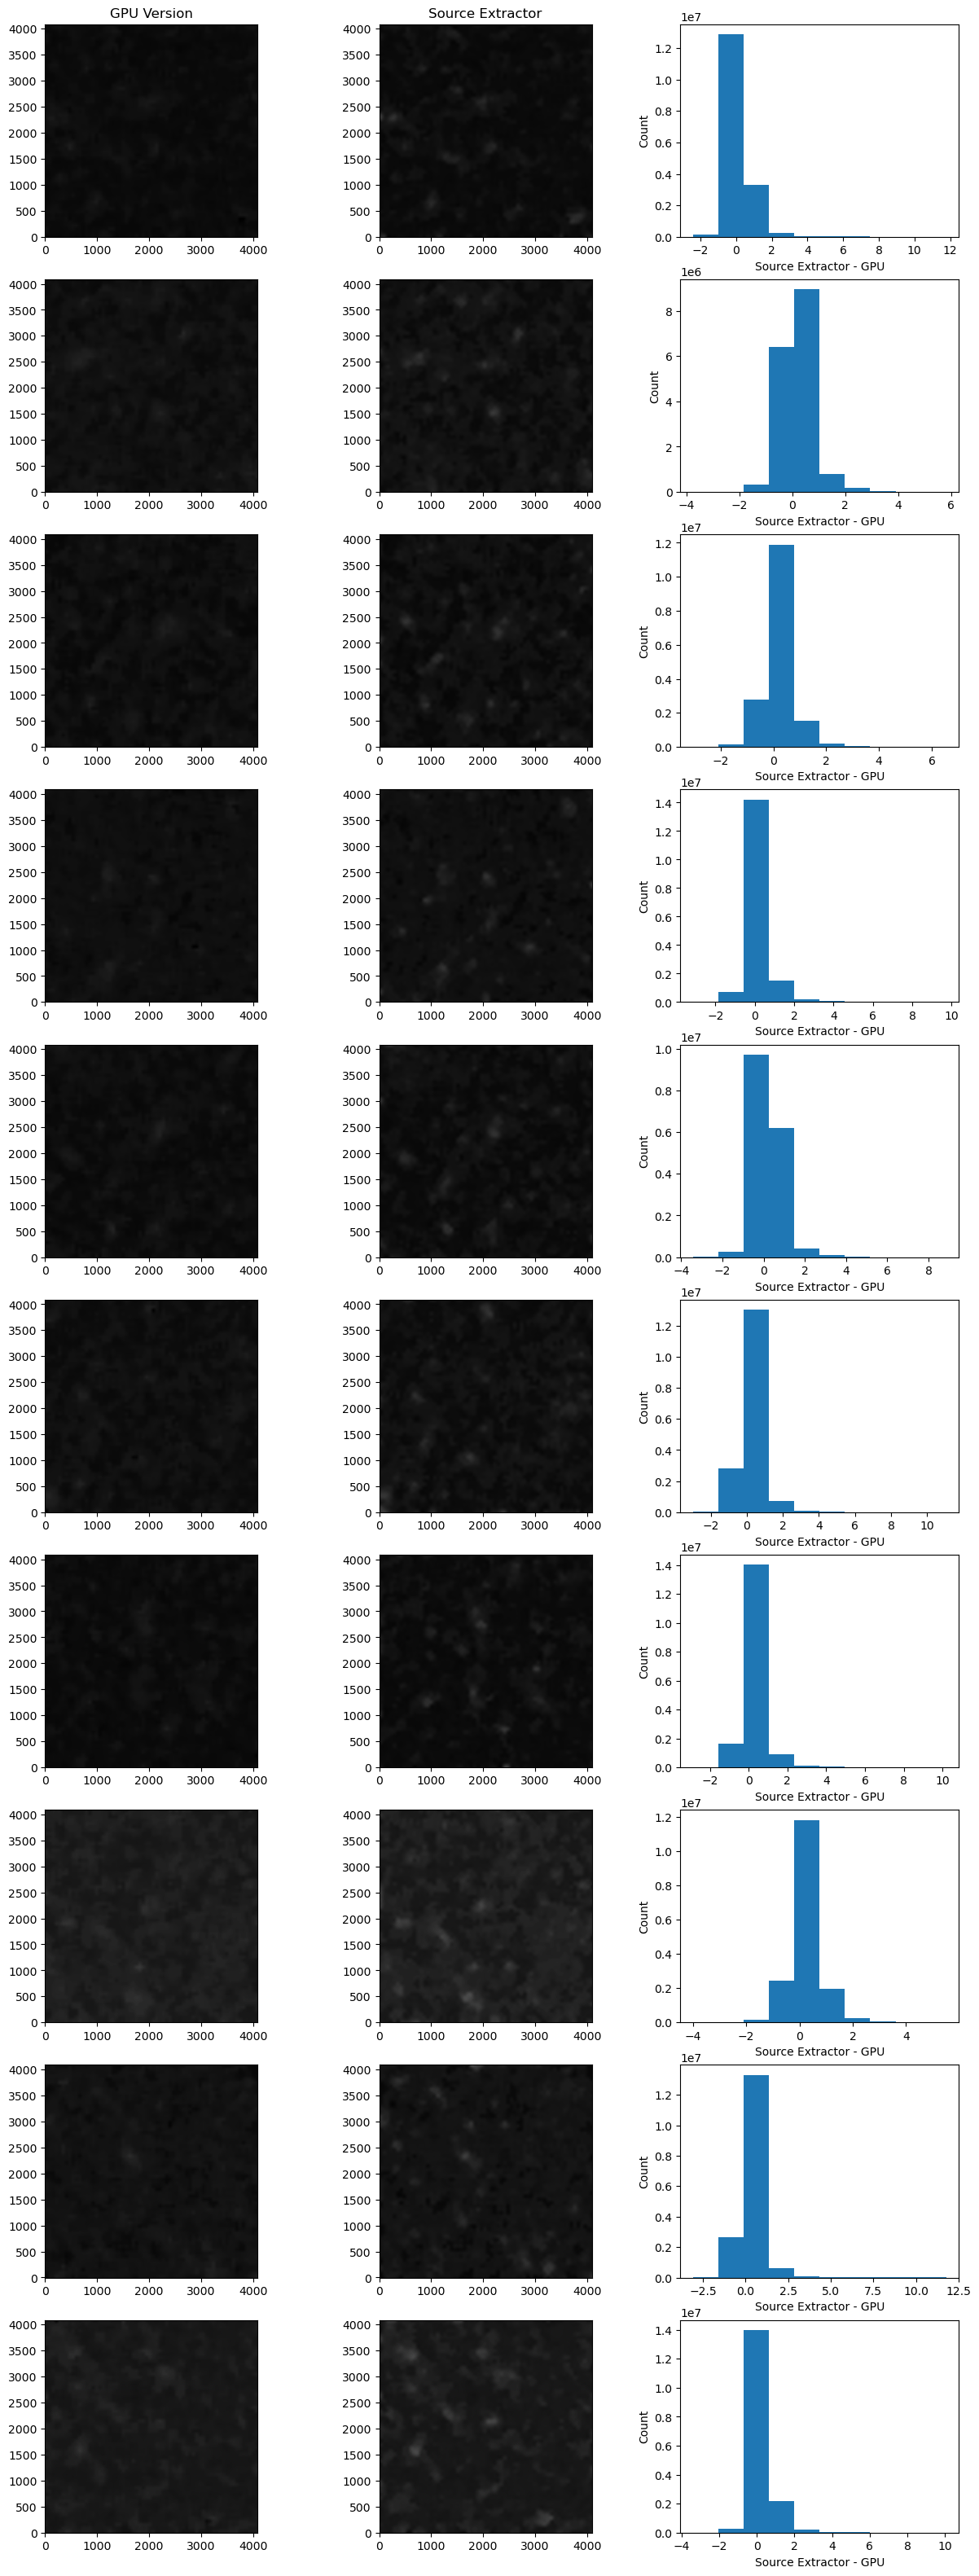

In [19]:
import pandas as pd
sne = pd.read_csv('./detect_supernova/test/test_ten_data_records_H158.csv')

fig, ax = plt.subplots(10, 3, figsize=(15, 40))
for idx, row in sne.iterrows():
    band = str(row['science_band'])
    pointing = int(row['science_pointing'])
    sca = int(row['science_sca'])
    science_id = {'band': band, 'pointing': pointing, 'sca': sca}
    science_path = INPUT_IMAGE_PATTERN.format(**science_id)
    science_image = load_image(science_path, hdu_id=1)
    science_skysub = load_image("./temp/skysub_Roman_TDS_simple_model_{band}_{pointing}_{sca}.fits.gz".format(**science_id))
    background, background_rms = sky_background_cupy(
        compute_background_map_raw, science_image, mesh_size=64, threads_per_block=(16, 16), n_sigma=5, max_iter=5)

    img1 = cp.asnumpy(background)
    img2 = science_image - science_skysub
    
    vmin = min(img1.min(), img2.min())
    vmax = max(img1.max(), img2.max())
    
    im0 = ax[idx][0].imshow(img1, cmap='gray', origin='lower', vmin=vmin, vmax=vmax*1.2)
    
    
    im1 = ax[idx][1].imshow(img2, cmap='gray', origin='lower', vmin=vmin, vmax=vmax*1.2)

    ax[idx][2].hist((img2 - img1).ravel())
    ax[idx][2].set_xlabel('Source Extractor - GPU')
    ax[idx][2].set_ylabel('Count')

    if idx == 0:
        ax[idx][0].set_title('GPU Version')
        ax[idx][1].set_title('Source Extractor')  

In [12]:
img1.min(), img1.max()

(113.62133860588074, 120.90770483016968)